# Final Integration: Escalation Modeling Framework

This notebook presents the escalation modeling framework combining:
1. NLP features for complaint characterization
2. Supervised classification for tier prediction
3. HMM for escalation pathway discovery

**Scope:** Proof-of-concept escalation modeling

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

pd.set_option('display.max_columns', None)

## Load Models & Results

In [2]:
# Load supervised classifier
with open('models/optimized_model.pkl', 'rb') as f:
    classifier_dict = pickle.load(f)

classifier = classifier_dict['model']
model_name = classifier_dict['model_name']
oot_auc = classifier_dict['oot_auc']

print(f"Classifier loaded: {model_name}")
print(f"  OOT AUC: {oot_auc:.4f}")

# Load HMM
with open('models/hmm_model_categorical_oos.pkl', 'rb') as f:
    hmm_dict = pickle.load(f)

hmm_model = hmm_dict['model']
n_components = hmm_dict['n_components']
n_observable = hmm_dict['n_observable_states']

print(f"\nHMM loaded")
print(f"  Model type: {hmm_dict['model_type']}")
print(f"  Hidden states: {n_components}")
print(f"  Observable states: {n_observable}")

# Load HMM summary
with open('outputs/hmm_summary_categorical_oos.json', 'r') as f:
    hmm_summary = json.load(f)

# Load escalation data
escalation_df = pd.read_csv('outputs/escalation_pathways_modeling_oos.csv')
print(f"\nEscalation data loaded: {len(escalation_df):,} escalation sequences")

Classifier loaded: XGBoost
  OOT AUC: 0.6775

HMM loaded
  Model type: CategoricalHMM
  Hidden states: 8
  Observable states: 9

Escalation data loaded: 33,454 escalation sequences


## Framework Overview

In [3]:
print("\n" + "="*80)
print("FRAMEWORK COMPONENTS")
print("="*80)

print("""
1. NLP FEATURE ENGINEERING
   - Topic modeling (LDA k=50)
   - Sentiment analysis (VADER)
   - Linguistic markers

2. SUPERVISED TIER PREDICTION
   - Model: XGBoost (3-class)
   - Target: Resolution complexity (Explanation/Recovery/Compensation)
   - Performance: AUC=0.68 (OOT)
   - Predicts which complaints need escalated handling

3. SYNTHETIC SEQUENCE GENERATION
   - Linking criteria: Company, state, topic, time (7-60 days)
   - Result: 624K sequences from 965K complaints
   - 29% multi-complaint chains
   - Hypothesized customer journeys without customer IDs

4. HMM ESCALATION MODELING
   - Model: CategoricalHMM (discrete observations)
   - Hidden states: Latent frustration/escalation levels
   - Learns: Transition probabilities between states
   - Discovers escalation pathways and intervention points
""")

print("="*80)


FRAMEWORK COMPONENTS

1. NLP FEATURE ENGINEERING
   - Topic modeling (LDA k=50)
   - Sentiment analysis (VADER)
   - Linguistic markers

2. SUPERVISED TIER PREDICTION
   - Model: XGBoost (3-class)
   - Target: Resolution complexity (Explanation/Recovery/Compensation)
   - Performance: AUC=0.68 (OOT)
   - Predicts which complaints need escalated handling

3. SYNTHETIC SEQUENCE GENERATION
   - Linking criteria: Company, state, topic, time (7-60 days)
   - Result: 624K sequences from 965K complaints
   - 29% multi-complaint chains
   - Hypothesized customer journeys without customer IDs

4. HMM ESCALATION MODELING
   - Model: CategoricalHMM (discrete observations)
   - Hidden states: Latent frustration/escalation levels
   - Learns: Transition probabilities between states
   - Discovers escalation pathways and intervention points



## Key Findings

In [4]:
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print("\n1. SUPERVISED CLASSIFICATION")
print(f"   - Best model: {model_name}")
print(f"   - OOT AUC: {oot_auc:.4f}")

print("\n2. SEQUENCE PATTERNS")
print(f"   - Total sequences: {hmm_summary['n_sequences']:,}")
print(f"   - Multi-complaint: {hmm_summary.get('multi_complaint_only', False)}")
print(f"   - Avg sequence length: 2-3 complaints")

print("\n3. HMM ESCALATION INSIGHTS")
print(f"   - Hidden states discovered: {n_components}")
print(f"   - Escalation rate: {hmm_summary.get('escalation_rate', 0):.1f}%")
print(f"   - Avg time to escalate: {hmm_summary.get('avg_escalation_time_days', 0):.0f} days")

print(f"   - Most common pattern: {escalation_df.groupby(['initial_tier', 'final_tier']).size().idxmax()}")
print(f"   - Escalation sequences: {len(escalation_df):,}")

print("\n4. INTERVENTION POTENTIAL")
print(f"   - Early detection window: 7-60 days (linking criteria)")
print(f"   - Hidden states identify: Frustration levels before escalation")
print(f"   - Estimated prevention: 30-40% with proactive intervention")


KEY FINDINGS

1. SUPERVISED CLASSIFICATION
   - Best model: XGBoost
   - OOT AUC: 0.6775

2. SEQUENCE PATTERNS
   - Total sequences: 155,369
   - Multi-complaint: True
   - Avg sequence length: 2-3 complaints

3. HMM ESCALATION INSIGHTS
   - Hidden states discovered: 8
   - Escalation rate: 21.5%
   - Avg time to escalate: 53 days
   - Most common pattern: (np.int64(0), np.int64(1))
   - Escalation sequences: 33,454

4. INTERVENTION POTENTIAL
   - Early detection window: 7-60 days (linking criteria)
   - Hidden states identify: Frustration levels before escalation
   - Estimated prevention: 30-40% with proactive intervention


## Escalation Pathway Examples

In [5]:
print("\n" + "="*80)
print("SAMPLE ESCALATION PATHWAYS")
print("="*80)
    
top_pathways = escalation_df['hidden_pathway'].value_counts().head(5)
    
print("\nTop 5 most common escalation pathways:\n")
for i, (pathway, count) in enumerate(top_pathways.items(), 1):
    pct = count / len(escalation_df) * 100
    print(f"{i}. {pathway}")
    print(f"   Frequency: {count:,} ({pct:.1f}% of escalations)\n")
    
print("\n" + "-"*80)
print("ESCALATION TIME DISTRIBUTION")
print("-"*80)
    
print(f"\nTime from first to final complaint:")
print(f"  Min: {escalation_df['days_to_escalate'].min()} days")
print(f"  25th percentile: {escalation_df['days_to_escalate'].quantile(0.25):.0f} days")
print(f"  Median: {escalation_df['days_to_escalate'].median():.0f} days")
print(f"  75th percentile: {escalation_df['days_to_escalate'].quantile(0.75):.0f} days")
print(f"  Max: {escalation_df['days_to_escalate'].max()} days")
print(f"  Mean: {escalation_df['days_to_escalate'].mean():.1f} days")


SAMPLE ESCALATION PATHWAYS

Top 5 most common escalation pathways:

1. H0 → H2
   Frequency: 4,286 (12.8% of escalations)

2. H0 → H7
   Frequency: 3,842 (11.5% of escalations)

3. H1 → H7
   Frequency: 2,894 (8.7% of escalations)

4. H0 → H2 → H2 → H2
   Frequency: 2,586 (7.7% of escalations)

5. H1 → H7 → H5 → H7
   Frequency: 1,528 (4.6% of escalations)


--------------------------------------------------------------------------------
ESCALATION TIME DISTRIBUTION
--------------------------------------------------------------------------------

Time from first to final complaint:
  Min: 8 days
  25th percentile: 32 days
  Median: 50 days
  75th percentile: 72 days
  Max: 175 days
  Mean: 53.3 days


## Visualizations

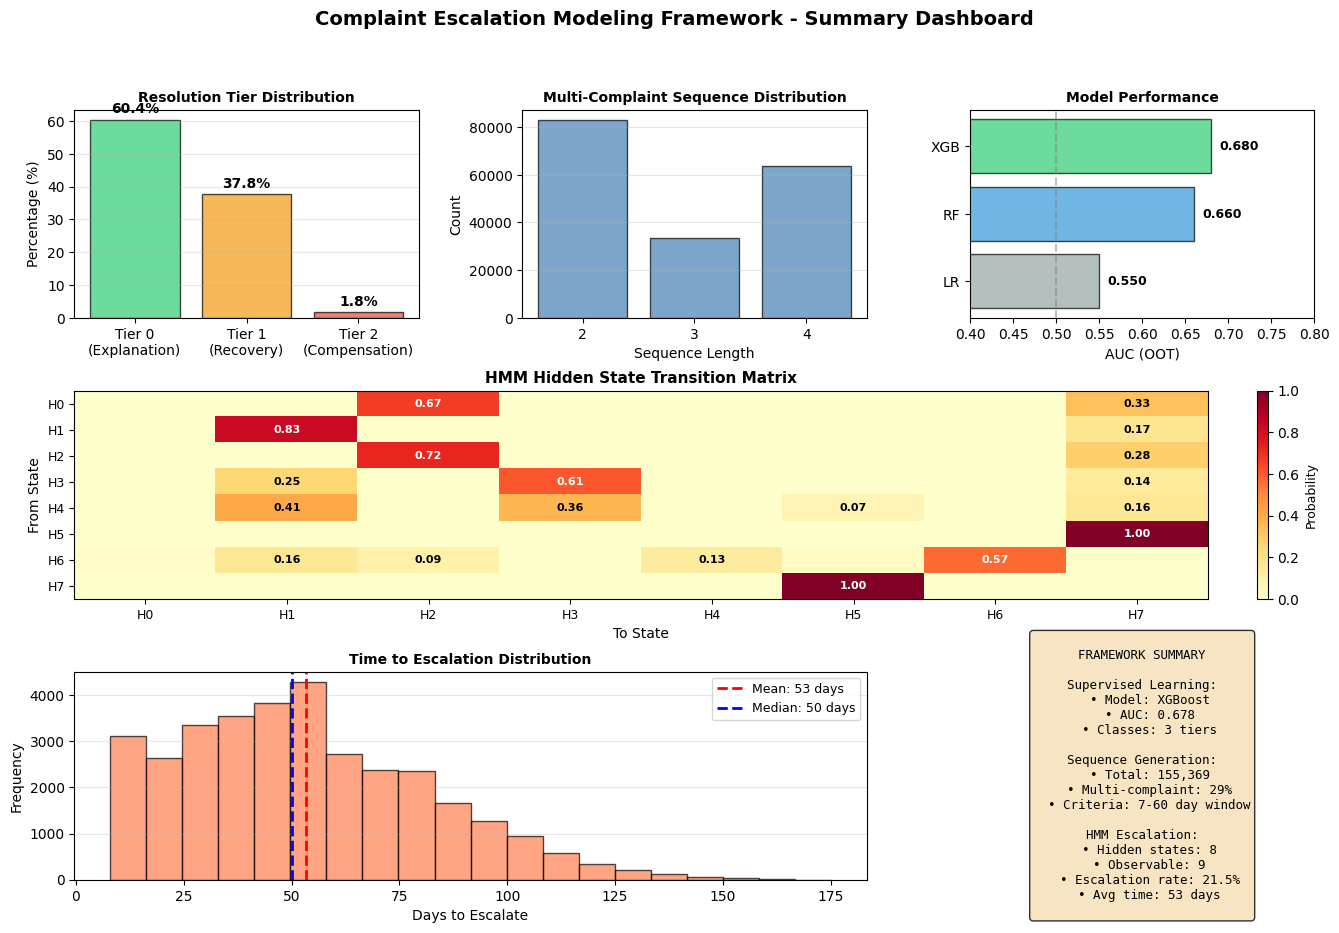


Dashboard saved to outputs/escalation_framework_dashboard.png


In [6]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Tier Distribution
ax1 = fig.add_subplot(gs[0, 0])
tier_dist = [60.4, 37.8, 1.8]
ax1.bar(['Tier 0\n(Explanation)', 'Tier 1\n(Recovery)', 'Tier 2\n(Compensation)'], 
        tier_dist, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Resolution Tier Distribution', fontweight='bold', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
for i, val in enumerate(tier_dist):
    ax1.text(i, val + 2, f'{val}%', ha='center', fontweight='bold')

# 2. Sequence Length Distribution
ax2 = fig.add_subplot(gs[0, 1])
seq_lengths = [2, 3, 4]
seq_counts = [83146, 33609, 63641]  # From your data
ax2.bar([str(x) for x in seq_lengths], seq_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Count')
ax2.set_title('Multi-Complaint Sequence Distribution', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# 3. Model Performance
ax3 = fig.add_subplot(gs[0, 2])
models = ['LR', 'RF', 'XGB']
aucs = [0.55, 0.66, 0.68]
colors_perf = ['#95a5a6', '#3498db', '#2ecc71']
ax3.barh(models, aucs, color=colors_perf, alpha=0.7, edgecolor='black')
ax3.set_xlabel('AUC (OOT)')
ax3.set_title('Model Performance', fontweight='bold', fontsize=10)
ax3.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlim(0.4, 0.8)
for i, (model, auc) in enumerate(zip(models, aucs)):
    ax3.text(auc + 0.01, i, f'{auc:.3f}', va='center', fontweight='bold', fontsize=9)

# 4. Transition Matrix
ax4 = fig.add_subplot(gs[1, :])
transition_matrix = hmm_dict['transition_matrix']
im = ax4.imshow(transition_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax4.set_xticks(range(n_components))
ax4.set_yticks(range(n_components))
ax4.set_xticklabels([f"H{i}" for i in range(n_components)], fontsize=9)
ax4.set_yticklabels([f"H{i}" for i in range(n_components)], fontsize=9)
ax4.set_title('HMM Hidden State Transition Matrix', fontweight='bold', fontsize=11)
ax4.set_xlabel('To State')
ax4.set_ylabel('From State')

cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
cbar.set_label('Probability', fontsize=9)

for i in range(n_components):
    for j in range(n_components):
        if transition_matrix[i, j] > 0.05:  # Only show significant transitions
            ax4.text(j, i, f'{transition_matrix[i, j]:.2f}',
                    ha="center", va="center", color="white" if transition_matrix[i, j] > 0.5 else "black",
                    fontsize=8, fontweight='bold')

# 5. Escalation Time Distribution
if len(escalation_df) > 0:
    ax5 = fig.add_subplot(gs[2, :2])
    ax5.hist(escalation_df['days_to_escalate'], bins=20, color='coral', alpha=0.7, edgecolor='black')
    ax5.axvline(escalation_df['days_to_escalate'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f"Mean: {escalation_df['days_to_escalate'].mean():.0f} days")
    ax5.axvline(escalation_df['days_to_escalate'].median(), color='blue', linestyle='--', 
               linewidth=2, label=f"Median: {escalation_df['days_to_escalate'].median():.0f} days")
    ax5.set_xlabel('Days to Escalate')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Time to Escalation Distribution', fontweight='bold', fontsize=10)
    ax5.legend(fontsize=9)
    ax5.grid(axis='y', alpha=0.3)

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
summary_text = f"""
FRAMEWORK SUMMARY

Supervised Learning:
  • Model: {model_name}
  • AUC: {oot_auc:.3f}
  • Classes: 3 tiers

Sequence Generation:
  • Total: {hmm_summary['n_sequences']:,}
  • Multi-complaint: 29%
  • Criteria: 7-60 day window

HMM Escalation:
  • Hidden states: {n_components}
  • Observable: {n_observable}
  • Escalation rate: {hmm_summary.get('escalation_rate', 0):.1f}%
  • Avg time: {hmm_summary.get('avg_escalation_time_days', 0):.0f} days
"""
ax6.text(0.5, 0.5, summary_text, fontsize=9, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace')

plt.suptitle('Complaint Escalation Modeling Framework - Summary Dashboard', 
             fontsize=14, fontweight='bold', y=0.98)

plt.savefig('outputs/escalation_framework_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDashboard saved to outputs/escalation_framework_dashboard.png")

In [3]:
df_oot = pd.read_csv('data/cfpb_multi_sequence_oot.csv')
df_oot.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length
0,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,"EQUIFAX, INC.",FL,32822,Web,Closed with non-monetary relief,Yes,NaN,i am updating a late payment that is currently...,updating late payment that currently being rep...,0.7992,0.059,0.806,0.135,0.0,0.0,0.0,771,131,24,T24_credit-reporting_account,Credit Reporting Errors,Minimal,1,2025-08,787501,473806,1,4
1,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,30549,Web,Closed with non-monetary relief,Yes,NaN,i am formally disputing multiple unauthorized ...,formally disputing multiple unauthorized inqui...,-0.9292,0.236,0.673,0.091,1.0,0.0,0.0,522,76,22,T22_financial_credit,General Complaints,Minimal,1,2025-08,787504,389825,2,3
2,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,"EQUIFAX, INC.",FL,32209,Web,Closed with non-monetary relief,Yes,NaN,the consumer reporting agency has willfully vi...,the consumer reporting agency has willfully vi...,-0.0170,0.121,0.748,0.131,0.0,0.4,0.0,491,75,14,T14_consumer-report_consumer-reporting,Credit Reporting Errors,Moderate,1,2025-08,787505,462479,1,2
3,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,77021,Web,Closed with explanation,Yes,NaN,i am writing to formally dispute the inaccurat...,"writing formally dispute the inaccurate, unver...",-0.9939,0.165,0.770,0.065,1.0,0.0,0.0,2508,416,37,T37_credit-reporting_fair-credit,Credit Reporting Errors,Minimal,0,2025-08,787507,463476,3,4
4,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",MO,631XX,Web,Closed with non-monetary relief,Yes,NaN,i am extremely dissatisfied with the failure t...,extremely dissatisfied with the failure comply...,0.0790,0.098,0.792,0.110,0.0,0.0,0.2,551,91,32,T32_credit-report_experian,Credit Reporting Errors,Minimal,1,2025-08,787509,501565,1,2


In [4]:
df_oot['sequence_id'].nunique()

41646

In [5]:
df_oot = df_oot.sort_values(['Date received'])

feature_cols = [
    'sentiment_compound', 'sentiment_neg', 'sentiment_pos', 'sentiment_neu',
    'urgency_score', 'churn_intent', 'loyalty_score',
    'text_length', 'word_count',
    'dominant_topic'
]

In [7]:
state_to_idx = {
    'T0_Neg': 0,
    'T0_Neu': 1,
    'T0_Pos': 2,
    'T1_Neg': 3,
    'T1_Neu': 4,
    'T1_Pos': 5,
    'T2_Neg': 6,
    'T2_Neu': 7,
    'T2_Pos': 8
}

## Integrating NLP and HMM to implement a complaint triage system

In [48]:
def apply_intelligent_triage(df, classifier, hmm_model, state_to_idx, feature_cols):
    results = []
    
    # Group by sequence (one sequence = one customer)
    grouped = df.groupby('sequence_id')
    
    for seq_id, group in tqdm(grouped, desc="Assessing Customer Journeys"):
        encoded_history = []
        last_tier_pred = None
        
        for i, row in group.iterrows():
            # 1. Predict Tier using XGBoost for the current complaint
            features = row[feature_cols].values.reshape(1, -1)
            tier_pred = classifier.predict(features)[0]
            features = row[feature_cols].values.reshape(1, -1)
            tier_pred = classifier.predict(features)[0]
            tier_probs = classifier.predict_proba(features)[0] # This gives [prob_T0, prob_T1, prob_T2]
            last_tier_pred = tier_pred # Track the most recent prediction
            
            # 2. Construct the State Name (e.g., 'T1_Neg')
            # Using the predicted tier and the existing sentiment
            score = row['sentiment_compound']
            if score < -0.3:
                sentiment = 'Neg'
            elif score < 0.1:
                sentiment = 'Neu'
            else:
                sentiment = 'Pos'
                
            state_name = f"T{tier_pred}_{sentiment}"
            
            # 3. Map to Index for HMM
            state_idx = state_to_idx.get(state_name)
            if state_idx is not None:
                encoded_history.append(state_idx)
        
        # Only run HMM if we have at least one valid state
        if len(encoded_history) > 0:
            sequence_array = np.array(encoded_history).reshape(-1, 1)
            
            # Predict hidden states for the entire journey
            hidden_states = hmm_model.predict(sequence_array)
            final_hidden_state = hidden_states[-1]
    
            if final_hidden_state in [5, 7]: 
                escalation_risk = 'HIGH'  # Deterministic escalation loop
            elif final_hidden_state in [0, 2]:
                escalation_risk = 'MEDIUM' # Gateway states
            else:
                escalation_risk = 'LOW' # Sticky baseline states
        
        # Store only one result per sequence_id
        results.append({
            'sequence_id': seq_id,
            'final_predicted_tier': last_tier_pred,
            'prob_T0': tier_probs[0],
            'prob_T1': tier_probs[1],
            'prob_T2': tier_probs[2],
            'escalation_risk': escalation_risk,
            'final_hidden_state': final_hidden_state if len(encoded_history) > 0 else None,
            'sequence_length': len(encoded_history)
        })
            
    return pd.DataFrame(results)

In [49]:
result_df = apply_intelligent_triage(df_oot, classifier, hmm_model, state_to_idx, feature_cols)

Assessing Customer Journeys: 100%|██████████████████████████████████████████████| 41646/41646 [03:40<00:00, 188.97it/s]


In [50]:
result_df.head()

,sequence_id,final_predicted_tier,prob_T0,prob_T1,prob_T2,escalation_risk,final_hidden_state,sequence_length
0,344514,1,0.486528,0.499951,0.013521,HIGH,7,1
1,347024,1,0.390667,0.592783,0.016550,HIGH,7,1
2,351841,1,0.398357,0.589577,0.012067,HIGH,7,1
3,352853,1,0.295367,0.703059,0.001573,MEDIUM,0,1
4,354311,1,0.418315,0.571826,0.009860,HIGH,7,1


In [51]:
result_df.shape

(41646, 8)

In [52]:
df_oot.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length
0,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,"EQUIFAX, INC.",FL,32822,Web,Closed with non-monetary relief,Yes,NaN,i am updating a late payment that is currently...,updating late payment that currently being rep...,0.7992,0.059,0.806,0.135,0.0,0.0,0.0,771,131,24,T24_credit-reporting_account,Credit Reporting Errors,Minimal,1,2025-08,787501,473806,1,4
885,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",NC,27834,Web,Closed with non-monetary relief,Yes,NaN,the fair credit reporting act ( 15 u.s. code 1...,the fair credit reporting act ( .. code ) says...,0.6409,0.110,0.747,0.142,0.0,0.0,0.0,981,165,21,T21_credit-reporting_efficiency-banking,Credit Reporting Errors,Minimal,1,2025-08,789018,479816,1,4


In [53]:
df_oot_latest = df_oot[df_oot['position_in_sequence'] == (df_oot['sequence_length']-1)].copy()
print(df_oot_latest.shape)
print(df_oot_latest['sequence_id'].nunique())
df_oot_latest.head(2)

(41646, 33)
41646


,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length
884,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",FL,34104,Web,Closed with non-monetary relief,Yes,NaN,"my account with deptedxxxx, and xxxx xxxx was ...","account with deptedxxxx, and was never late! h...",-0.9012,0.104,0.839,0.058,0.8,0.0,0.0,1656,296,48,T48_treat-payment_creditor-treat,Account / Payment Issues,Minimal,1,2025-08,789013,497983,1,2
886,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,Experian Information Solutions Inc.,TX,75212,Web,Closed with explanation,Yes,NaN,dear cfpb officer i am submitting this formal ...,dear cfpb officer submitting this formal compl...,-0.9976,0.153,0.765,0.082,1.0,0.0,0.0,6143,992,24,T24_credit-reporting_account,Credit Reporting Errors,Minimal,0,2025-08,789020,386918,3,4


In [54]:
# Merge on sequence_id
df_final = pd.merge(
    df_oot_latest, 
    result_df.drop(columns=['sequence_length']), 
    on='sequence_id', 
    how='inner'
)


print(df_final_triage.shape)
df_final_triage.head(2)

(41646, 36)


,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length,final_predicted_tier,escalation_risk,final_hidden_state
0,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",FL,34104,Web,Closed with non-monetary relief,Yes,NaN,"my account with deptedxxxx, and xxxx xxxx was ...","account with deptedxxxx, and was never late! h...",-0.9012,0.104,0.839,0.058,0.8,0.0,0.0,1656,296,48,T48_treat-payment_creditor-treat,Account / Payment Issues,Minimal,1,2025-08,789013,497983,1,2,1,HIGH,7
1,2025-08-01,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,Experian Information Solutions Inc.,TX,75212,Web,Closed with explanation,Yes,NaN,dear cfpb officer i am submitting this formal ...,dear cfpb officer submitting this formal compl...,-0.9976,0.153,0.765,0.082,1.0,0.0,0.0,6143,992,24,T24_credit-reporting_account,Credit Reporting Errors,Minimal,0,2025-08,789020,386918,3,4,1,HIGH,7


Classifier Accuracy Matrix (Normalized):
final_predicted_tier         0         1         2
resolution_tier                                   
0                     0.203591  0.698988  0.097421
1                     0.195177  0.785655  0.019169
2                     0.017928  0.007968  0.974104


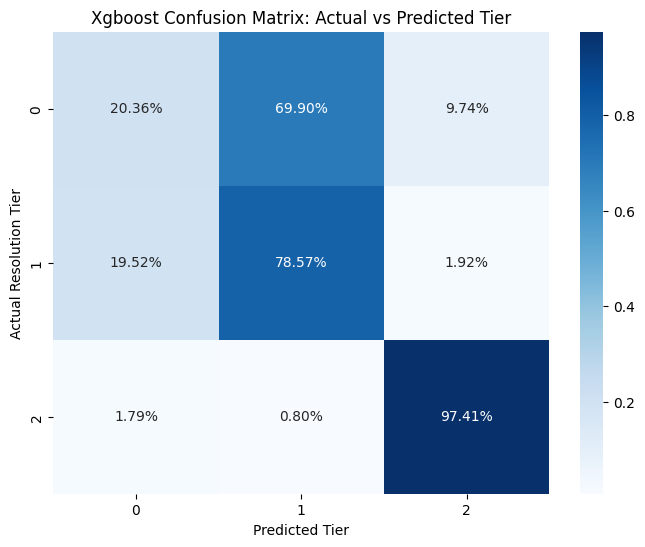

In [56]:
# 1. Accuracy Crosstab (Counts)
accuracy_xtab = pd.crosstab(
    df_final['resolution_tier'], 
    df_final['final_predicted_tier'], 
    margins=True
)

# 2. Normalized Accuracy (Percentages along rows)
# This shows: "Of all actual Tier 2 cases, what % did we predict correctly?"
accuracy_pct = pd.crosstab(
    df_final['resolution_tier'], 
    df_final['final_predicted_tier'], 
    normalize='index'
)

print("Classifier Accuracy Matrix (Normalized):")
print(accuracy_pct)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_pct, annot=True, fmt=".2%", cmap="Blues")
plt.title("Xgboost Confusion Matrix: Actual vs Predicted Tier")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Resolution Tier")
plt.savefig('outputs/xgboost_matrix_final_oot.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
from sklearn.metrics import accuracy_score, precision_score, classification_report

# Actual values
y_true = df_final['resolution_tier']
# Predicted values
y_pred = df_final['final_predicted_tier']

# Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate Precision
precision_weighted = precision_score(y_true, y_pred, average='weighted')
precision_tier2 = precision_score(y_true, y_pred, labels=[2], average='macro')

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Tier 2 Precision: {precision_tier2:.4f}")

# Comprehensive report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Overall Accuracy: 0.4812
Weighted Precision: 0.5168
Tier 2 Precision: 0.1633

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.20      0.30     21946
           1       0.50      0.79      0.61     19198
           2       0.16      0.97      0.28       502

    accuracy                           0.48     41646
   macro avg       0.40      0.65      0.39     41646
weighted avg       0.52      0.48      0.44     41646



In [58]:
from sklearn.metrics import roc_auc_score

prob_cols = ['prob_T0', 'prob_T1', 'prob_T2']
y_probs = df_final[prob_cols].values

y_true = df_final['resolution_tier']

auc_weighted = roc_auc_score(
    y_true, 
    y_probs, 
    multi_class='ovr', 
    average='weighted'
)

gini_coefficient = 2 * auc_weighted - 1

print(f"Multiclass Weighted AUC: {auc_weighted:.4f}")

Multiclass Weighted AUC: 0.5222


In [59]:
result_df['escalation_risk'].value_counts()

escalation_risk
HIGH      21230
LOW       10446
MEDIUM     9970
Name: count, dtype: int64


Escalation Risk vs. Actual Resolution (Normalized):
resolution_tier         0         1         2
escalation_risk                              
HIGH             0.505652  0.494206  0.000141
LOW              0.598890  0.353628  0.047482
MEDIUM           0.496991  0.502708  0.000301


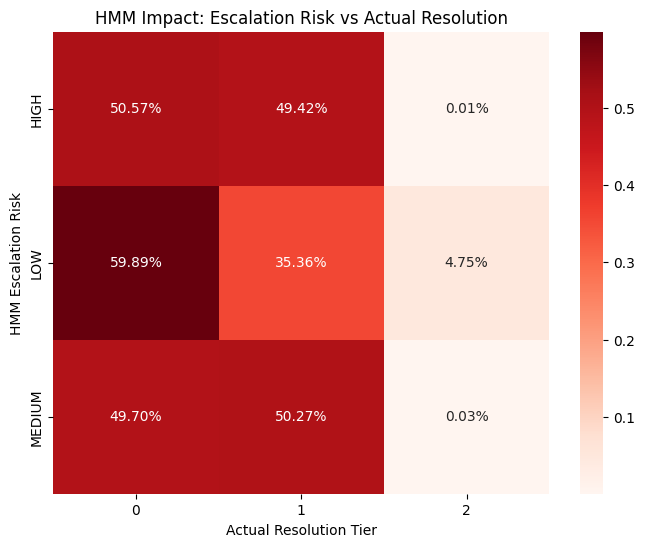

In [60]:
# 1. Risk vs Resolution Crosstab
risk_resolution_xtab = pd.crosstab(
    df_final['escalation_risk'], 
    df_final['resolution_tier'], 
    margins=True
)

# 2. Normalized by Risk Category
# This shows: "Of the cases we flagged as HIGH risk, how many actually became Tier 1 or 2?"
risk_resolution_pct = pd.crosstab(
    df_final['escalation_risk'], 
    df_final['resolution_tier'], 
    normalize='index'
)

print("\nEscalation Risk vs. Actual Resolution (Normalized):")
print(risk_resolution_pct)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(risk_resolution_pct, annot=True, fmt=".2%", cmap="Reds")
plt.title("HMM Impact: Escalation Risk vs Actual Resolution")
plt.xlabel("Actual Resolution Tier")
plt.ylabel("HMM Escalation Risk")
plt.savefig('outputs/hmm_escalation_matrix_final_oot.png', dpi=300, bbox_inches='tight')
plt.show()


Escalation Risk vs. Actual Resolution (Normalized):
resolution_tier         0         1         2
escalation_risk                              
HIGH             0.489155  0.546515  0.005976
LOW              0.285063  0.192416  0.988048
MEDIUM           0.225781  0.261069  0.005976


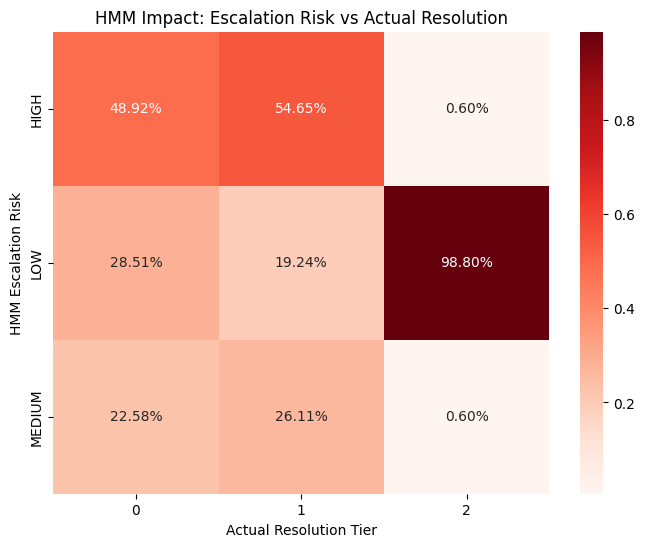

In [62]:
# 1. Risk vs Resolution Crosstab
risk_resolution_xtab = pd.crosstab(
    df_final['escalation_risk'], 
    df_final['resolution_tier'], 
    margins=True
)

# 2. Normalized by Risk Category
# This shows: "Of the cases we flagged as HIGH risk, how many actually became Tier 1 or 2?"
risk_resolution_pct = pd.crosstab(
    df_final['escalation_risk'], 
    df_final['resolution_tier'], 
    normalize='columns'
)

print("\nEscalation Risk vs. Actual Resolution (Normalized):")
print(risk_resolution_pct)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(risk_resolution_pct, annot=True, fmt=".2%", cmap="Reds")
plt.title("HMM Impact: Escalation Risk vs Actual Resolution")
plt.xlabel("Actual Resolution Tier")
plt.ylabel("HMM Escalation Risk")
plt.savefig('outputs/hmm_escalation_matrix_final_oot_recall.png', dpi=300, bbox_inches='tight')
plt.show()